<a href="https://colab.research.google.com/github/vcanio/MineriaDeDatos/blob/Alonso-Escobar/Premier__Alonso_Escobar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importamos librerías esenciales para manipulación de datos (Pandas, Numpy)
# y visualización (Matplotlib, Seaborn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Ajustamos la visualización de Pandas para evitar que trunque las columnas o filas importantes
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100) # Es mejor poner un límite como 100 para no saturar la memoria visual

In [2]:
# Cargamos el dataset histórico de la Premier League
df = pd.read_csv("/content/epl_final.csv")

# Verificamos las dimensiones del dataset (cantidad de filas y columnas)
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (9380, 22)


In [3]:
# Inspeccionamos las primeras y últimas filas para confirmar que los datos se cargaron correctamente
display(df.head())
display(df.tail())

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,12,14,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,5,13,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,11,7,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,17,11,7,2,3,6,10,11,2,2,0,0
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,20,12,3,4,7,4,9,15,3,8,0,0


# **Diccionario de Datos**

Season: La temporada (e.g., 2020–2021)

MatchDate: La fecha en que se jugó el partido

HomeTeam: Nombre del equipo local

AwayTeam: Nombre del equipo visitante

FullTimeHomeGoals: Goles marcados por el equipo local (tiempo completo)

FullTimeAwayGoals: Goles marcados por el equipo visitante (tiempo completo)

FullTimeResult: Resultado del partido (H = Victoria local, A = Victoria visitante, D = Empate)

HalfTimeHomeGoals: Goles marcados por el equipo local (descanso)

HalfTimeAwayGoals: Goles marcados por el equipo visitante (descanso)

HalfTimeResult: Resultado al descanso (H = Victoria local, V = Victoria visitante, D = Empate)

HomeShots: Tiros totales del equipo local

AwayShots: Tiros totales del equipo visitante

HomeShotsOnTarget: Tiros a puerta del equipo local

AwayShotsOnTarget: Tiros a puerta del equipo visitante

HomeCorners: Número de saques de esquina conseguidos por el equipo local

AwayCorners: Número de saques de esquina conseguidos por el equipo visitante

HomeFouls: Número de faltas cometidas por el equipo local

AwayFouls: Número de faltas cometidas por el equipo visitante

HomeYellowCards: Tarjetas amarillas recibidas por el equipo local

AwayYellowCards: Tarjetas amarillas recibidas por el equipo visitante

HomeRedCards: Tarjetas rojas recibidas por el equipo local

AwayRedCards: Tarjetas rojas recibidas por el equipo visitante

In [4]:
# Revisamos los tipos de datos (strings, enteros, etc.) para saber si necesitamos conversiones
df.dtypes

,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object


In [5]:
# Buscamos si existen valores nulos que debamos imputar o eliminar
df.isnull().sum()

,0
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


In [6]:
# Resumen estadístico de las variables numéricas (promedios, mínimos, máximos)
df.describe()

# --- Análisis de Categorías ---

# Vemos la distribución de partidos jugados como local por cada equipo
cant_team_df = df['HomeTeam'].value_counts()
print("Top equipos jugando de local:")
print(cant_team_df.head())
print(f"Total de equipos únicos: {cant_team_df.count()}\n")

# Analizamos la distribución de los resultados a tiempo completo y al medio tiempo
cant_full_time_df = df['FullTimeResult'].value_counts()
cant_half_time_df = df['HalfTimeResult'].value_counts()
print(f"Resultados Finales:\n{cant_full_time_df}\n")
print(f"Resultados Medio Tiempo:\n{cant_half_time_df}")

Top equipos jugando de local:
HomeTeam
Everton       471
Chelsea       469
Tottenham     469
Man United    469
Arsenal       468
Name: count, dtype: int64
Total de equipos únicos: 46

Resultados Finales:
FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64

Resultados Medio Tiempo:
HalfTimeResult
D    3840
H    3290
A    2250
Name: count, dtype: int64


/tmp/ipykernel_4063/1709667841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=cant_full_time_df.index, y=cant_full_time_df.values, palette='viridis')


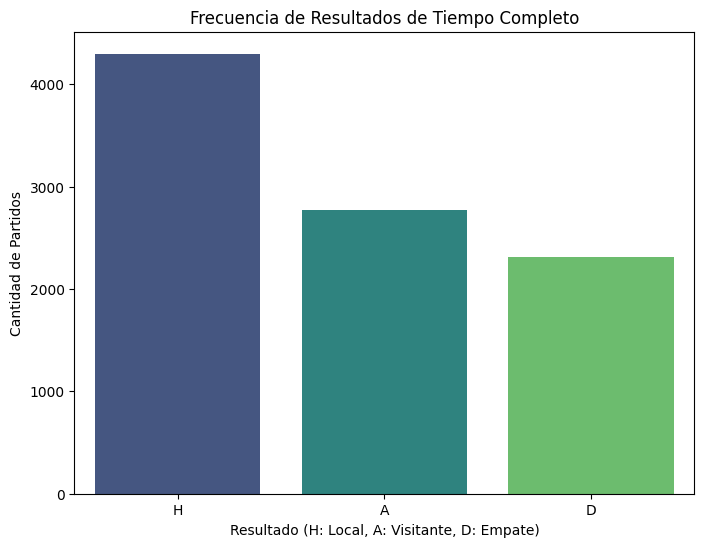

In [7]:
# --- Visualizaciones ---

# Visualizamos la ventaja de la localía: comparamos victorias locales (H), visitantes (A) y empates (D)
plt.figure(figsize=(8, 6))
sb.barplot(x=cant_full_time_df.index, y=cant_full_time_df.values, palette='viridis')
plt.title('Frecuencia de Resultados de Tiempo Completo')
plt.xlabel('Resultado (H: Local, A: Visitante, D: Empate)')
plt.ylabel('Cantidad de Partidos')
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

# Inicializamos el codificador para transformar variables categóricas (texto) a numéricas
label_encoder = LabelEncoder()

# Transformamos los resultados del partido (H, D, A) en números enteros
df['FullTimeResult_Encoded'] = label_encoder.fit_transform(df['FullTimeResult'])

# Guardamos e imprimimos el diccionario de mapeo para no olvidar qué número es qué resultado
print("Mapeo de FullTimeResult:")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} : {i}")

# Repetimos el proceso para los resultados del medio tiempo
df['HalfTimeResult_Encoded'] = label_encoder.fit_transform(df['HalfTimeResult'])

# Verificamos que las nuevas columnas codificadas se hayan integrado bien
display(df[['FullTimeResult', 'FullTimeResult_Encoded', 'HalfTimeResult', 'HalfTimeResult_Encoded']].head())

Mapeo de FullTimeResult:
A : 0
D : 1
H : 2


,FullTimeResult,FullTimeResult_Encoded,HalfTimeResult,HalfTimeResult_Encoded
0,H,2,H,2
1,H,2,H,2
2,A,0,D,1
3,D,1,A,0
4,H,2,H,2


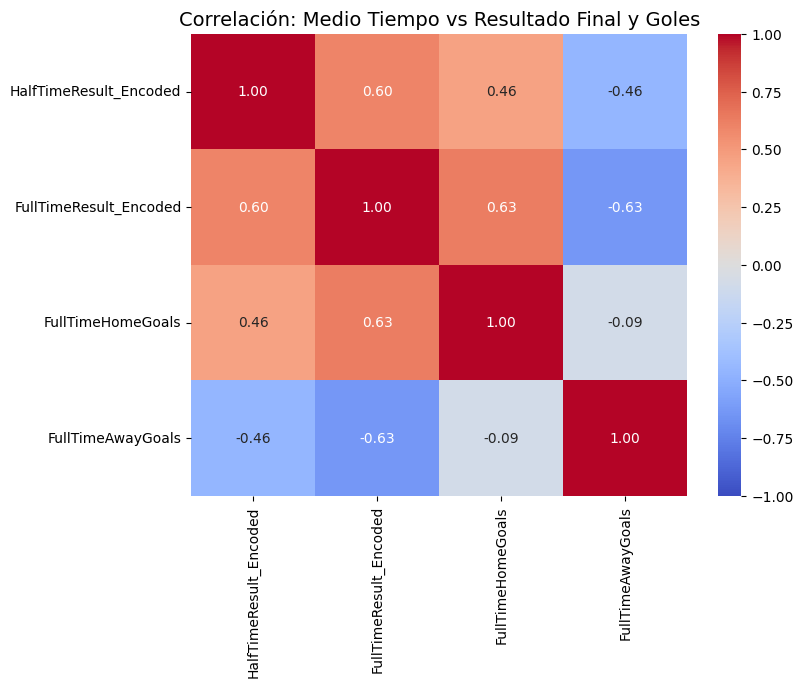

In [9]:
# -------------------------------------------------------------------
# Análisis 1: Matriz de Correlación con las variables codificadas
# -------------------------------------------------------------------
plt.figure(figsize=(8, 6))

# Seleccionamos las variables numéricas clave, incluyendo tus columnas codificadas
columnas_corr = ['HalfTimeResult_Encoded', 'FullTimeResult_Encoded', 'FullTimeHomeGoals', 'FullTimeAwayGoals']
matriz_correlacion = df[columnas_corr].corr()

# Generamos el heatmap con una paleta divergente para destacar correlaciones positivas y negativas
sb.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Correlación: Medio Tiempo vs Resultado Final y Goles", fontsize=14)
plt.show()

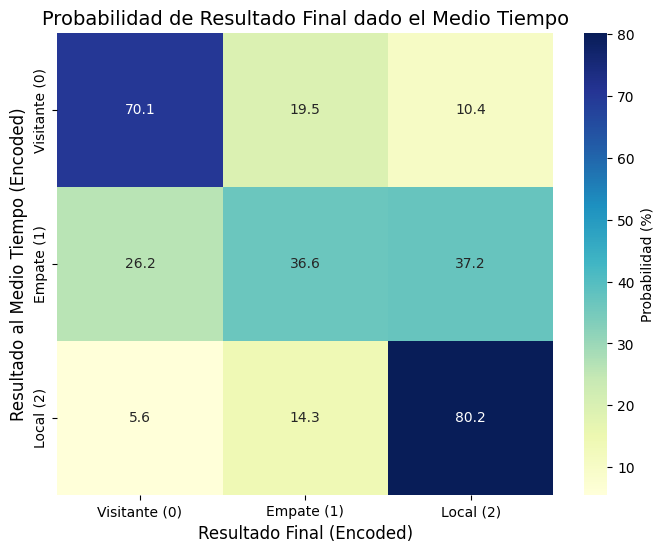

In [10]:
# -------------------------------------------------------------------
# Análisis 2: Probabilidad de victoria según la ventaja al medio tiempo
# -------------------------------------------------------------------
plt.figure(figsize=(8, 6))

# Creamos la tabla cruzada usando exclusivamente tus columnas _Encoded
# normalize='index' convierte los conteos en porcentajes por fila
tabla_transicion = pd.crosstab(df['HalfTimeResult_Encoded'], df['FullTimeResult_Encoded'], normalize='index') * 100

# Añadimos etiquetas legibles en la gráfica para recordar el mapeo del LabelEncoder
nombres_ejes = ['Visitante (0)', 'Empate (1)', 'Local (2)']
tabla_transicion.index = nombres_ejes
tabla_transicion.columns = nombres_ejes

# Graficamos
sb.heatmap(tabla_transicion, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': 'Probabilidad (%)'})

plt.title('Probabilidad de Resultado Final dado el Medio Tiempo', fontsize=14)
plt.ylabel('Resultado al Medio Tiempo (Encoded)', fontsize=12)
plt.xlabel('Resultado Final (Encoded)', fontsize=12)
plt.show()

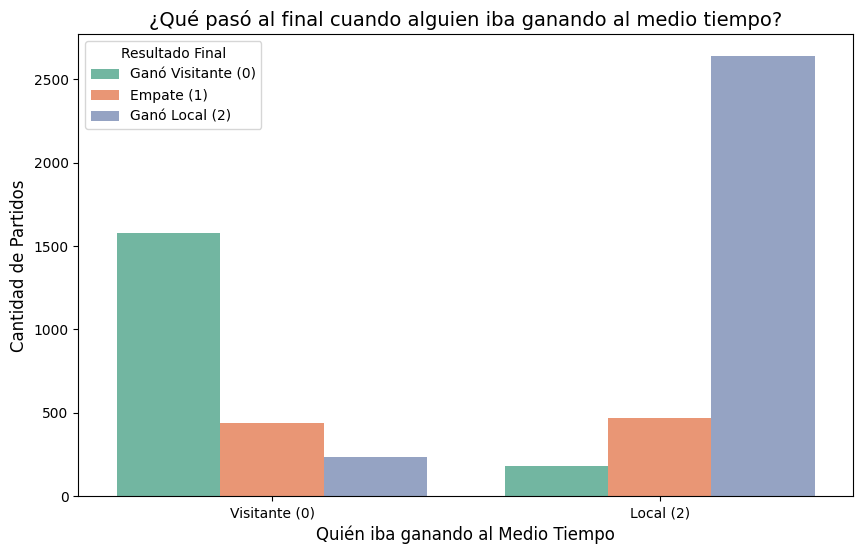

In [11]:
# -------------------------------------------------------------------
# Análisis 3: Cantidad de partidos donde se mantuvo la victoria del medio tiempo
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Filtramos solo los partidos donde alguien iba ganando al medio tiempo (excluyendo empates = 1)
partidos_con_ventaja_mt = df[df['HalfTimeResult_Encoded'].isin([0, 2])]

# Usamos seaborn para graficar el resultado final, separando por quién iba ganando al medio tiempo
sb.countplot(data=partidos_con_ventaja_mt,
             x='HalfTimeResult_Encoded',
             hue='FullTimeResult_Encoded',
             palette='Set2')

# Ajustes de diseño
plt.title("¿Qué pasó al final cuando alguien iba ganando al medio tiempo?", fontsize=14)
plt.xlabel("Quién iba ganando al Medio Tiempo", fontsize=12)
plt.ylabel("Cantidad de Partidos", fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Visitante (0)', 'Local (2)'])
plt.legend(title='Resultado Final', labels=['Ganó Visitante (0)', 'Empate (1)', 'Ganó Local (2)'])

plt.show()

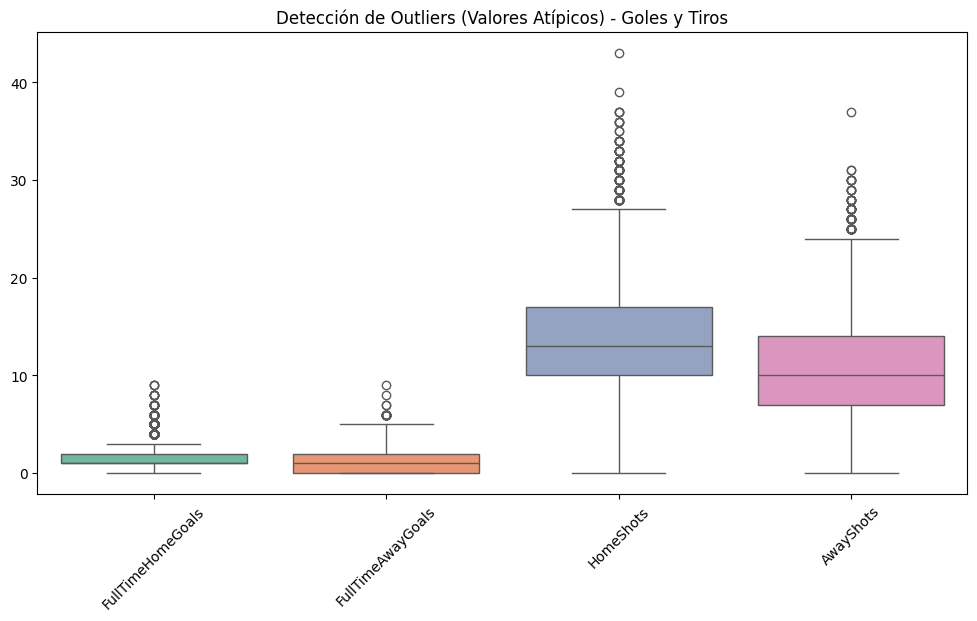

In [12]:
# -------------------------------------------------------------------
# Boxplot para detectar Outliers (Valores Atípicos) en Goles y Tiros
# -------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Seleccionamos variables numéricas clave de interés
cols_numericas_futbol = ['FullTimeHomeGoals', 'FullTimeAwayGoals', 'HomeShots', 'AwayShots']

# Generamos el boxplot
sb.boxplot(data=df[cols_numericas_futbol], palette="Set2")

plt.xticks(rotation=45)
plt.title('Detección de Outliers (Valores Atípicos) - Goles y Tiros')
plt.show()

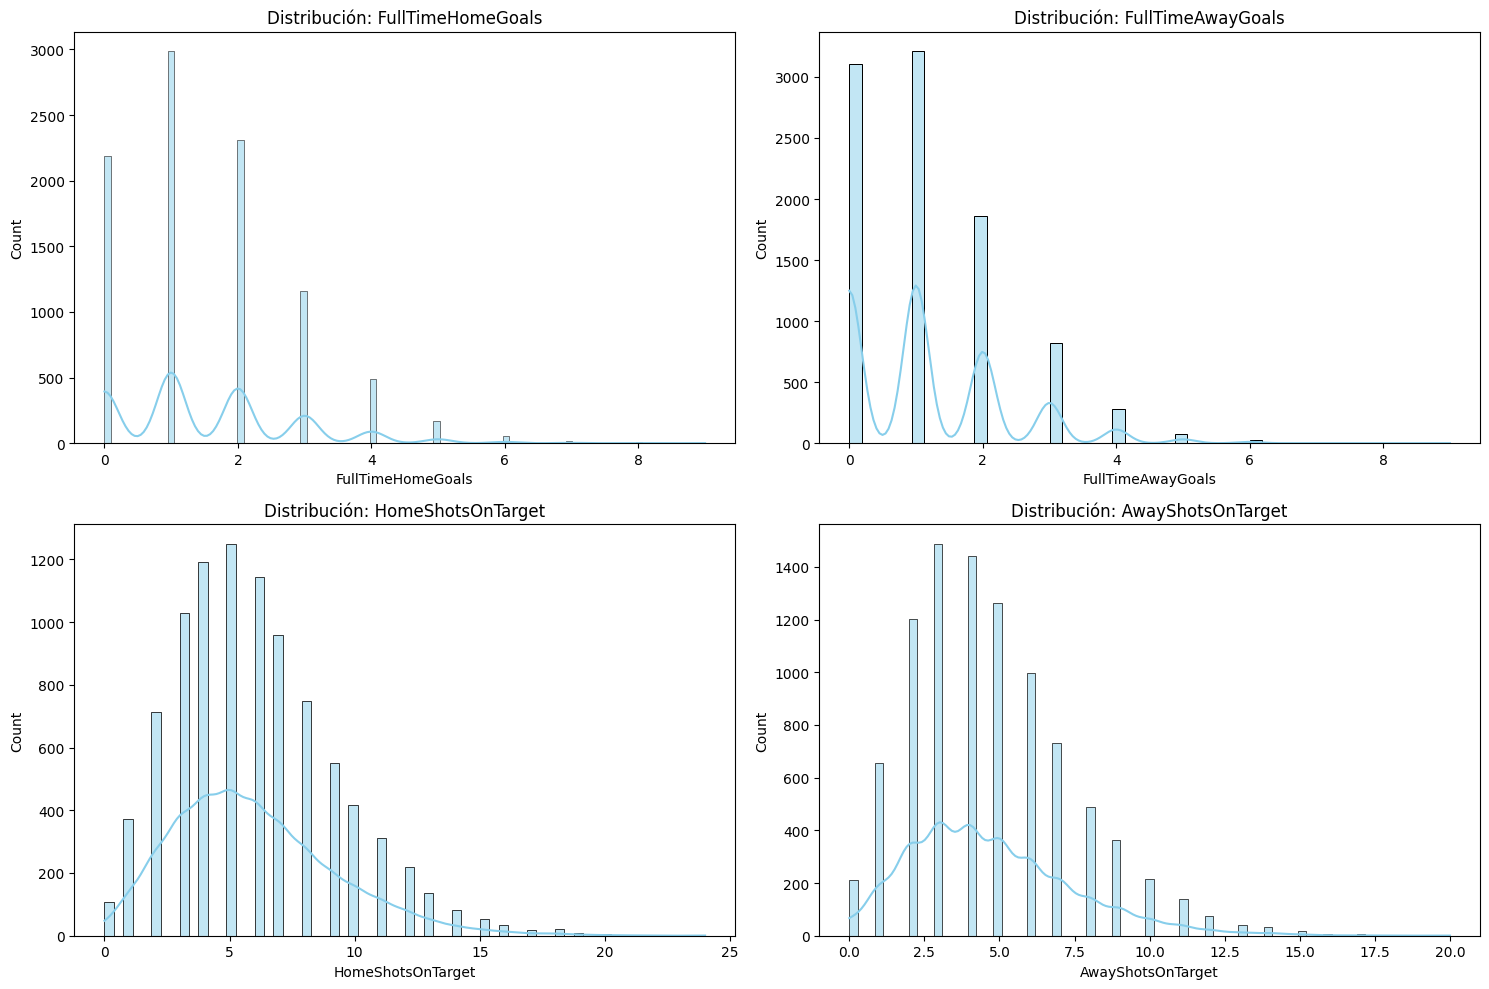

In [13]:
# -------------------------------------------------------------------
# Distribución de Variables Numéricas (Histogramas con curva de densidad)
# -------------------------------------------------------------------
# Lista de columnas numéricas (similar al procedimiento de clase)
cols_distribucion = ['FullTimeHomeGoals', 'FullTimeAwayGoals', 'HomeShotsOnTarget', 'AwayShotsOnTarget']

# Configuración de la figura, con subplots (2 filas, 2 columnas)
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_distribucion, 1):
    plt.subplot(2, 2, i)
    sb.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

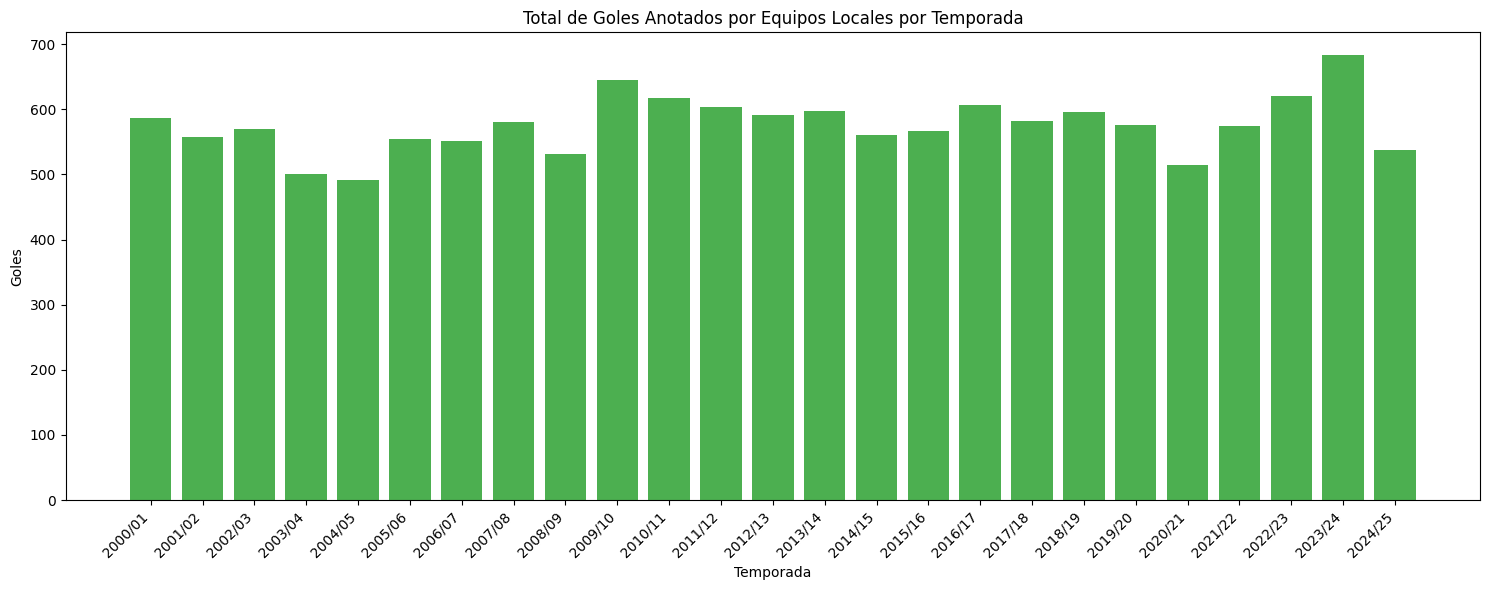

In [14]:
# -------------------------------------------------------------------
# Total de Goles de Locales agrupados por Temporada (Uso de Groupby)
# -------------------------------------------------------------------
# Agrupamos por temporada y sumamos los goles
resumen_temporada = df.groupby('Season')['FullTimeHomeGoals'].sum().reset_index()

# Ordenamos por temporada
resumen_temporada = resumen_temporada.sort_values(by='Season')

plt.figure(figsize=(15, 6))
# Gráfico de barras
plt.bar(resumen_temporada['Season'], resumen_temporada['FullTimeHomeGoals'], color="#4CAF50")

plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas para que no choquen
plt.title("Total de Goles Anotados por Equipos Locales por Temporada")
plt.xlabel("Temporada")
plt.ylabel("Goles")
plt.tight_layout()
plt.show()

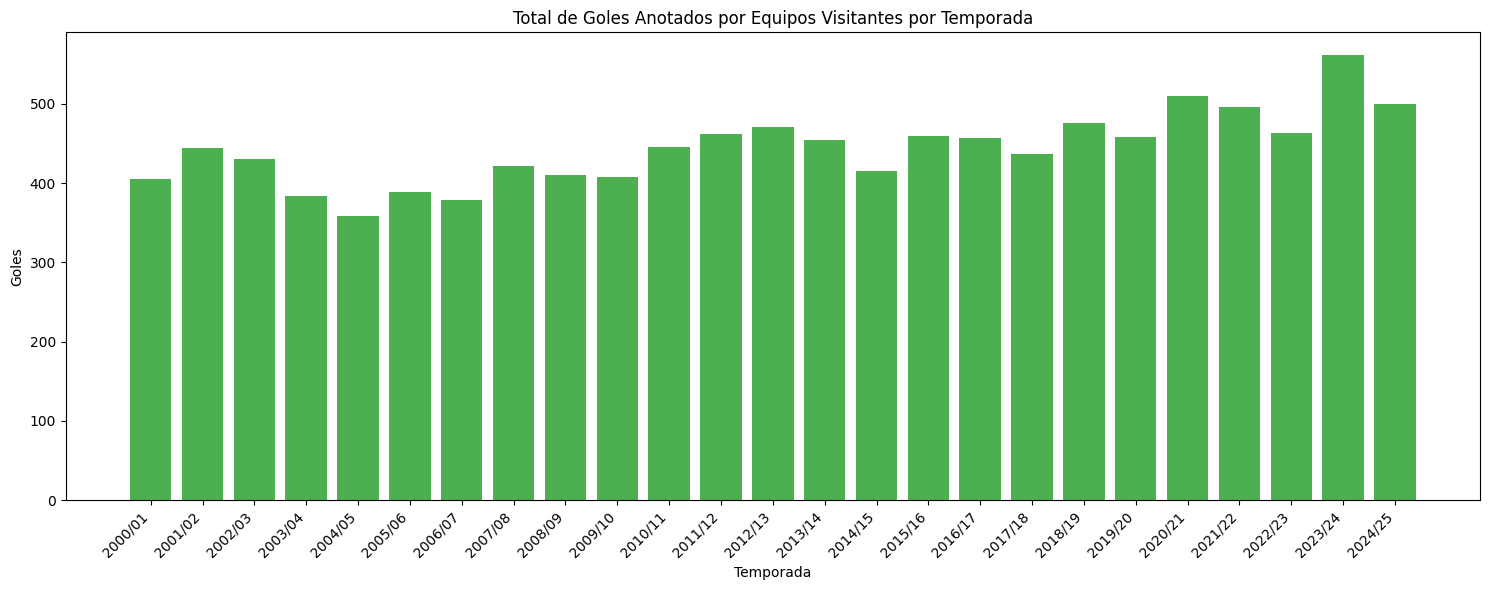

In [16]:
# -------------------------------------------------------------------
# Total de Goles de Locales agrupados por Temporada (Uso de Groupby)
# -------------------------------------------------------------------
# Agrupamos por temporada y sumamos los goles
resumen_temporada = df.groupby('Season')['FullTimeAwayGoals'].sum().reset_index()

# Ordenamos por temporada
resumen_temporada = resumen_temporada.sort_values(by='Season')

plt.figure(figsize=(15, 6))
# Gráfico de barras
plt.bar(resumen_temporada['Season'], resumen_temporada['FullTimeAwayGoals'], color="#4CAF50")

plt.xticks(rotation=45, ha='right') # Rotamos las etiquetas para que no choquen
plt.title("Total de Goles Anotados por Equipos Visitantes por Temporada")
plt.xlabel("Temporada")
plt.ylabel("Goles")
plt.tight_layout()
plt.show()

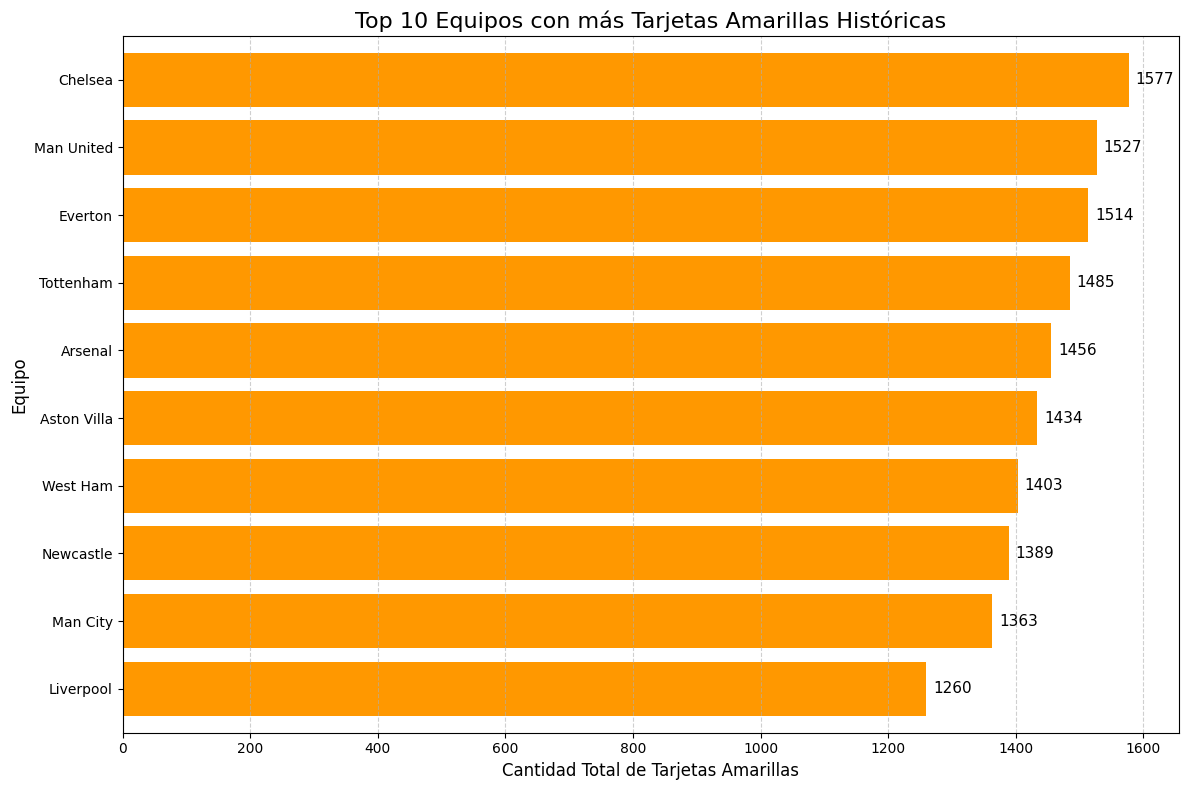

In [17]:
# -------------------------------------------------------------------
# Top 10 Equipos con más Tarjetas Amarillas (Gráfico de Barras Horizontal)
# -------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Sumamos las amarillas de local y de visitante por equipo
amarillas_local = df.groupby('HomeTeam')['HomeYellowCards'].sum()
amarillas_visita = df.groupby('AwayTeam')['AwayYellowCards'].sum()

# Sumamos ambas series, rellenamos nulos con 0, ordenamos de mayor a menor y sacamos el Top 10
total_amarillas = amarillas_local.add(amarillas_visita, fill_value=0).sort_values(ascending=True).tail(10)

# Graficamos al estilo del profesor (barras horizontales)
ax = total_amarillas.plot(kind='barh', width=0.8, color='#ff9800')

# Añadimos las etiquetas exactas al final de cada barra
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, color='black')

plt.title("Top 10 Equipos con más Tarjetas Amarillas Históricas", fontsize=16)
plt.xlabel("Cantidad Total de Tarjetas Amarillas", fontsize=12)
plt.ylabel("Equipo", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Guardamos el gráfico
plt.savefig('top10_tarjetas_amarillas.png', dpi=100)
plt.show()

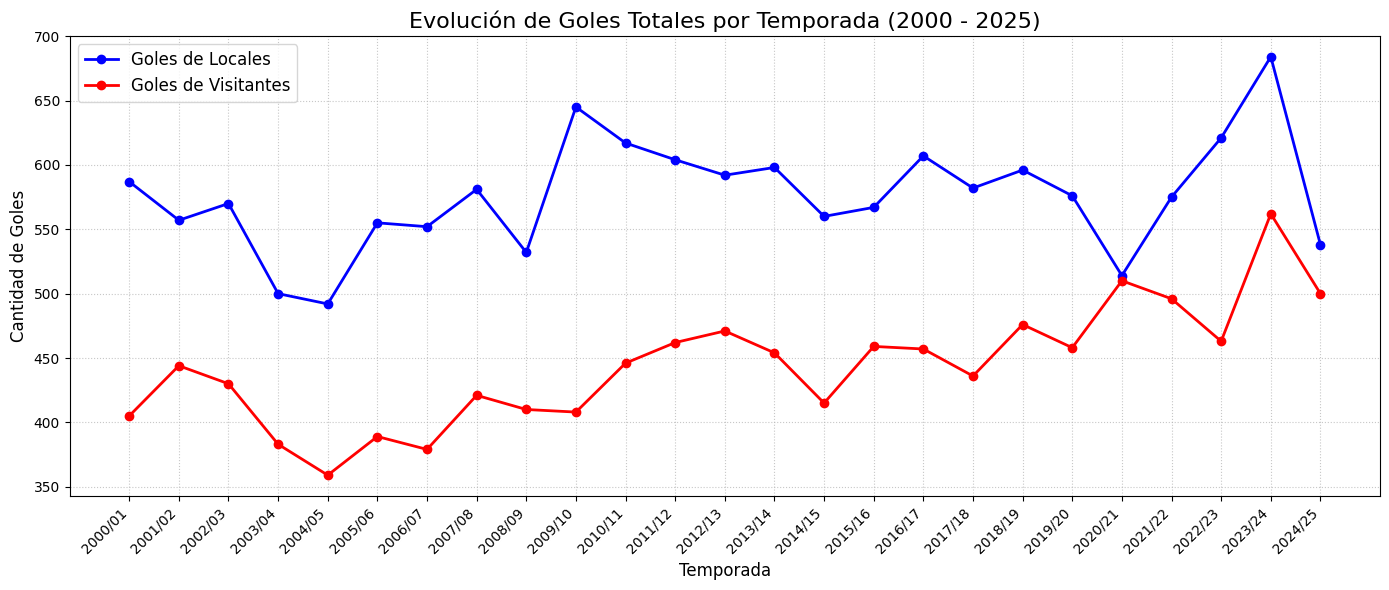

In [18]:
# -------------------------------------------------------------------
# Evolución de Goles por Temporada (Gráfico de Líneas)
# -------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Agrupamos los goles por temporada
goles_temporada = df.groupby('Season')[['FullTimeHomeGoals', 'FullTimeAwayGoals']].sum().reset_index()
# Ordenamos las temporadas cronológicamente
goles_temporada = goles_temporada.sort_values(by='Season')

# Graficamos dos líneas: Locales vs Visitantes
plt.plot(goles_temporada['Season'], goles_temporada['FullTimeHomeGoals'], marker='o', label='Goles de Locales', color='blue', linewidth=2)
plt.plot(goles_temporada['Season'], goles_temporada['FullTimeAwayGoals'], marker='o', label='Goles de Visitantes', color='red', linewidth=2)

plt.title("Evolución de Goles Totales por Temporada (2000 - 2025)", fontsize=16)
plt.xlabel("Temporada", fontsize=12)
plt.ylabel("Cantidad de Goles", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Guardamos el gráfico
plt.savefig('evolucion_goles_temporada.png', dpi=100)
plt.show()

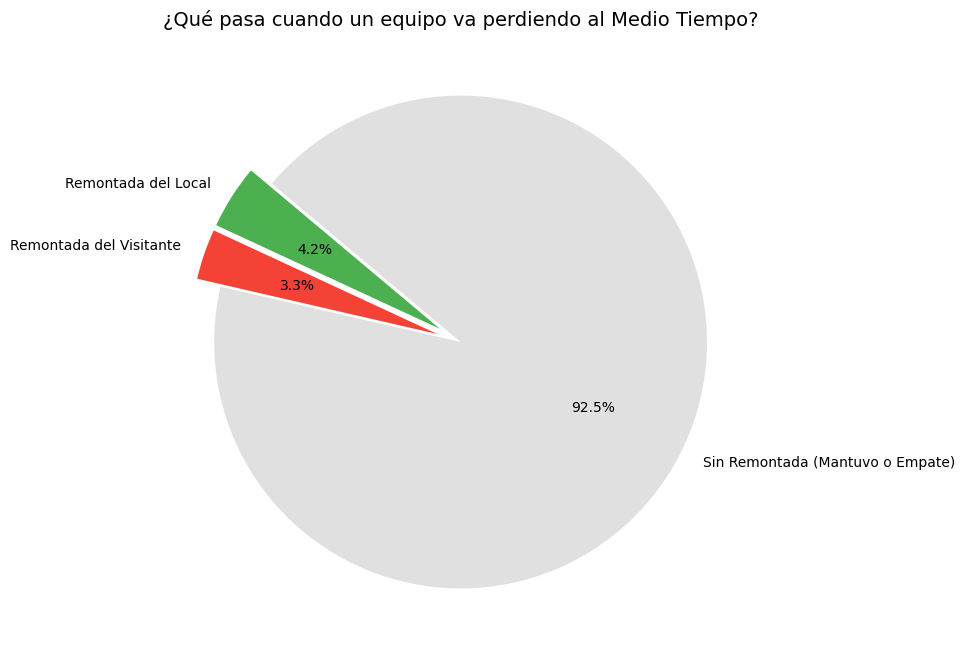

In [19]:
# -------------------------------------------------------------------
# Proporción de Remontadas (Gráfico de Pastel)
# -------------------------------------------------------------------
plt.figure(figsize=(8, 8))

# Filtramos las remontadas (Iba perdiendo al Medio Tiempo, pero ganó al Final)
remontadas_local = df[(df['HalfTimeResult'] == 'A') & (df['FullTimeResult'] == 'H')]
remontadas_visita = df[(df['HalfTimeResult'] == 'H') & (df['FullTimeResult'] == 'A')]

# Partidos donde alguien iba ganando al medio tiempo y NO hubo remontada (mantuvo ventaja o empató)
otros_resultados = df[df['HalfTimeResult'].isin(['H', 'A'])]
cantidad_no_remontadas = len(otros_resultados) - (len(remontadas_local) + len(remontadas_visita))

# Datos para el Pie Chart
valores = [len(remontadas_local), len(remontadas_visita), cantidad_no_remontadas]
etiquetas = ['Remontada del Local', 'Remontada del Visitante', 'Sin Remontada (Mantuvo o Empate)']
colores = ['#4CAF50', '#F44336', '#E0E0E0']

# Graficamos al estilo del profesor
plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', colors=colores, startangle=140, explode=(0.1, 0.1, 0))
plt.title("¿Qué pasa cuando un equipo va perdiendo al Medio Tiempo?", fontsize=14)

# Guardamos el gráfico
plt.savefig('pastel_remontadas.png', dpi=100)
plt.show()